<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_6_Capstone_WorkforceIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 6 – Machine Learning Fundamentals

# Capstone Project: WorkforceIQ — Employee Attrition Risk Prediction System

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

Employee attrition is a major challenge for organizations because losing experienced employees can increase recruitment costs, reduce productivity, and affect team performance.

In this capstone project, I develop an end-to-end machine learning solution that predicts employee attrition risk using HR-related features such as job role, overtime, monthly income, satisfaction levels, work-life balance, and years at the company.

The project covers the complete machine learning workflow: problem definition, data cleaning, exploratory data analysis, feature engineering, preprocessing, model training, model comparison, best-model selection, model saving, and deployment through a Streamlit web application.

## Problem Statement

Organizations often struggle to identify employees who may be at risk of leaving before resignation occurs. Employee turnover can result in recruitment expenses, onboarding costs, loss of knowledge, and reduced productivity.

The objective of this project is to build a machine learning model that estimates employee attrition risk based on historical HR data. The model is intended to act as a decision-support tool that may help HR teams identify patterns associated with attrition and design proactive retention strategies.

## Project Objectives

The main objectives of this capstone project are:

- Understand and clean the HR employee attrition dataset.
- Perform Exploratory Data Analysis (EDA).
- Identify important factors associated with employee attrition.
- Create meaningful engineered features.
- Handle numerical and categorical variables using a preprocessing pipeline.
- Train multiple classification models.
- Compare model performance using appropriate evaluation metrics.
- Select the best-performing model.
- Save the complete trained model using Joblib.
- Build an interactive Streamlit application.
- Deploy the final machine learning solution as a live web app.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib
import os

print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset

The project uses the IBM HR Analytics Employee Attrition dataset.

The dataset contains employee information related to:

- Demographics
- Job role
- Salary
- Satisfaction
- Work-life balance
- Overtime
- Career history
- Attrition status

The target variable is `Attrition`.

In [2]:
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
df = pd.read_csv(
    "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1470
Number of columns: 35


## Initial Dataset Inspection

Before building any machine learning model, the dataset is inspected to understand its structure, feature types, and potential data quality issues.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [7]:
missing_values = df.isnull().sum()

print(
    missing_values[
        missing_values > 0
    ]
)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

Series([], dtype: int64)

Total missing values: 0


In [8]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [9]:
print("Attrition Distribution:")
print(df["Attrition"].value_counts())

print("\nAttrition Percentage:")
print(
    (
        df["Attrition"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

Attrition Distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Percentage:
Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


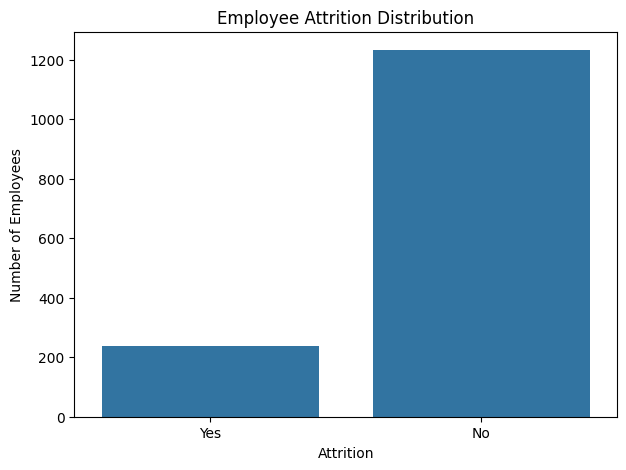

In [10]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

## Exploratory Data Analysis

Exploratory Data Analysis is used to identify patterns between employee characteristics and attrition.

The first analysis examines whether overtime is associated with employee attrition.

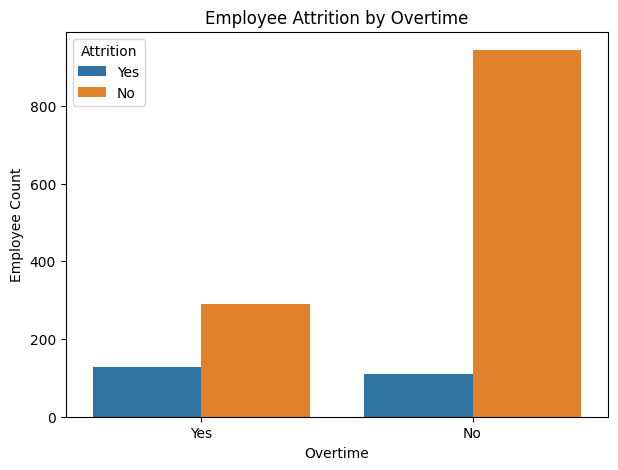

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Employee Attrition by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.show()

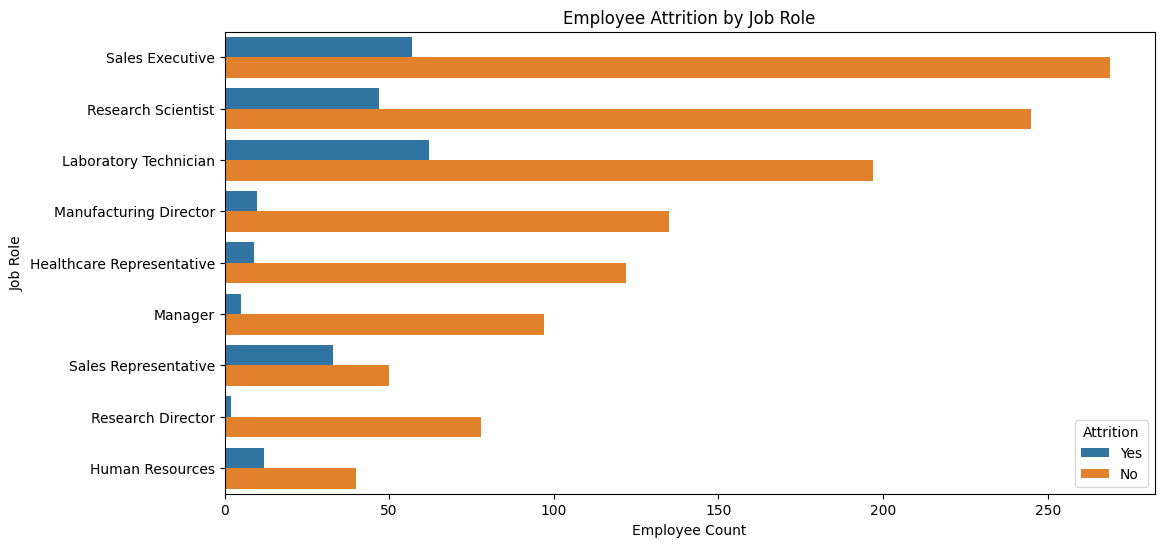

In [12]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition"
)

plt.title("Employee Attrition by Job Role")
plt.xlabel("Employee Count")
plt.ylabel("Job Role")

plt.show()

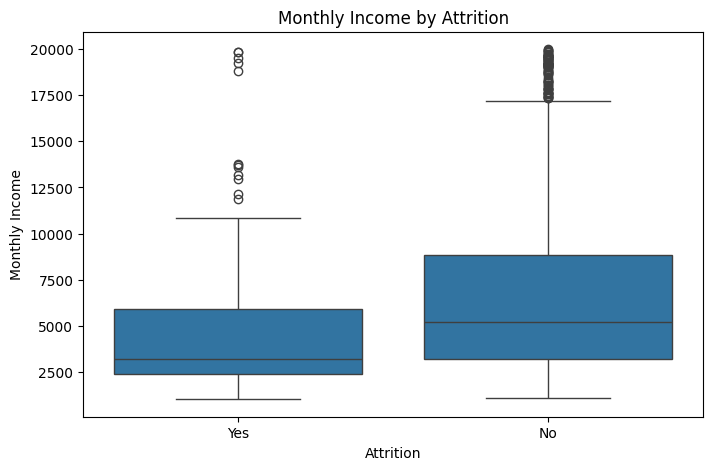

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

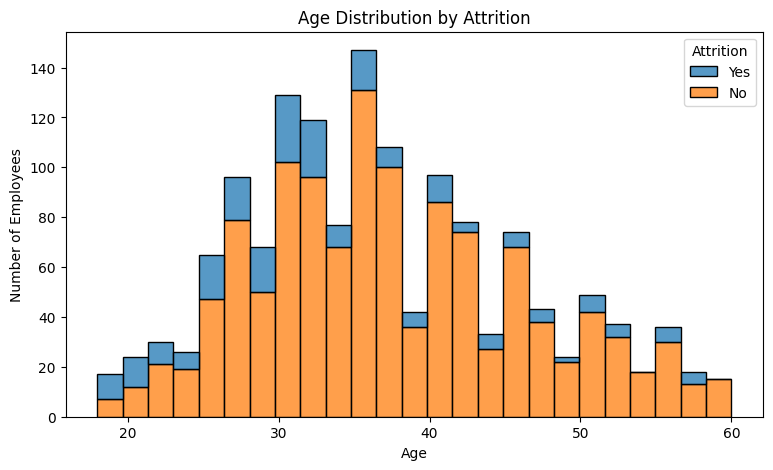

In [15]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    bins=25,
    multiple="stack"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

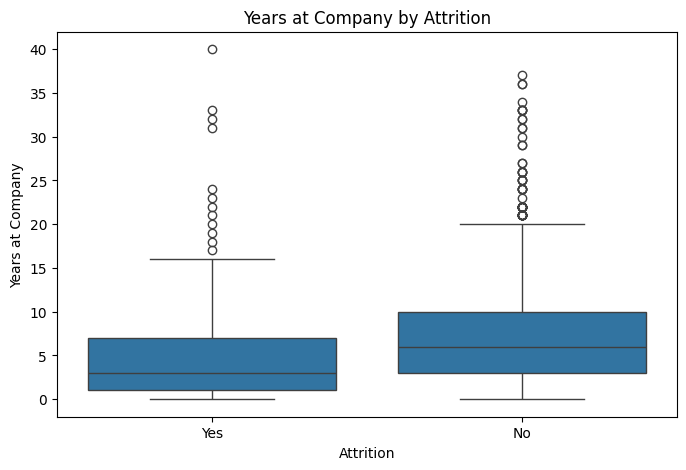

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

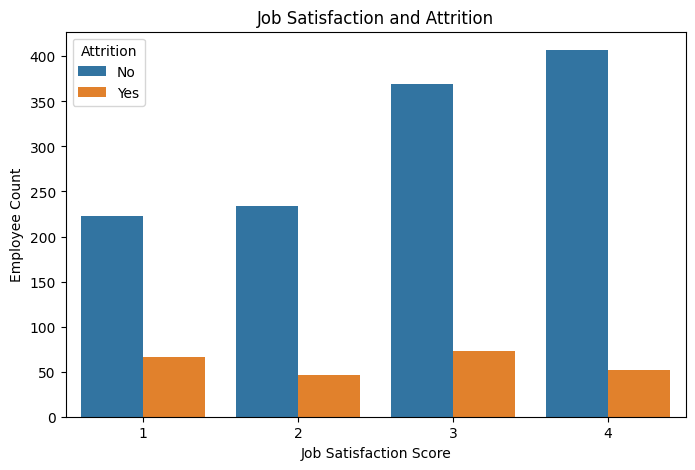

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction and Attrition")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Employee Count")

plt.show()

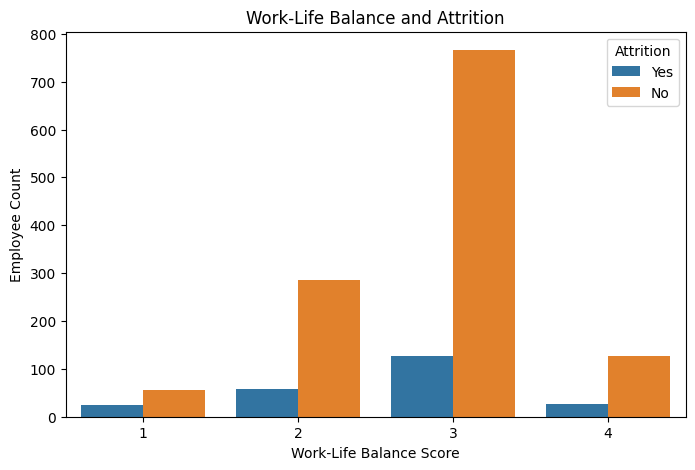

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance and Attrition")
plt.xlabel("Work-Life Balance Score")
plt.ylabel("Employee Count")

plt.show()

## Data Cleaning

Certain columns contain constant values or identifiers that do not provide useful predictive information. These features are removed before model development.

In [18]:
columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(
    columns=columns_to_drop,
    errors="ignore"
)

print("Remaining columns:", df.shape[1])

Remaining columns: 31


## Target Encoding

The target variable `Attrition` is converted into numerical form:

- `No` = 0
- `Yes` = 1

In [19]:
df["Attrition"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


## Feature Engineering

Feature engineering creates new variables from existing information that may help the models capture additional patterns.

The following engineered features are created:

### TotalSatisfaction

Combines job satisfaction, environment satisfaction, relationship satisfaction, and work-life balance.

### CompanyTenureRatio

Measures how much of an employee's total working experience has been spent at the current company.

### IncomePerYearExperience

Represents monthly income relative to total working experience.

### PromotionGap

Represents the number of years since the employee's last promotion relative to their time at the company.

In [20]:
df["TotalSatisfaction"] = (
    df["JobSatisfaction"]
    + df["EnvironmentSatisfaction"]
    + df["RelationshipSatisfaction"]
    + df["WorkLifeBalance"]
)

df["TotalSatisfaction"].head()

,TotalSatisfaction
0,8
1,12
2,12
3,13
4,10


In [21]:
df["CompanyTenureRatio"] = (
    df["YearsAtCompany"]
    / (df["TotalWorkingYears"] + 1)
)

df["CompanyTenureRatio"].head()

,CompanyTenureRatio
0,0.666667
1,0.909091
2,0.000000
3,0.888889
4,0.285714


In [22]:
df["IncomePerYearExperience"] = (
    df["MonthlyIncome"]
    / (df["TotalWorkingYears"] + 1)
)

df["IncomePerYearExperience"].head()

,IncomePerYearExperience
0,665.888889
1,466.363636
2,261.250000
3,323.222222
4,495.428571


In [23]:
df["PromotionGap"] = (
    df["YearsAtCompany"]
    - df["YearsSinceLastPromotion"]
)

df["PromotionGap"].head()

,PromotionGap
0,6
1,9
2,0
3,5
4,0


In [24]:
df[
    [
        "TotalSatisfaction",
        "CompanyTenureRatio",
        "IncomePerYearExperience",
        "PromotionGap"
    ]
].head()

,TotalSatisfaction,CompanyTenureRatio,IncomePerYearExperience,PromotionGap
0,8,0.666667,665.888889,6
1,12,0.909091,466.363636,9
2,12,0.000000,261.250000,0
3,13,0.888889,323.222222,5
4,10,0.285714,495.428571,0


In [25]:
X = df.drop(
    "Attrition",
    axis=1
)

y = df["Attrition"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1470, 34)
Target shape: (1470,)


In [26]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(
    "Numerical Features:",
    len(numerical_columns)
)

print(
    "Categorical Features:",
    len(categorical_columns)
)

Numerical Features: 27
Categorical Features: 7


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratification is used so that the proportion of employees who left remains approximately consistent in both sets.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1176, 34)
Testing data: (294, 34)


In [28]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [29]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

## Data Preprocessing Pipeline

Numerical and categorical variables require different preprocessing.

- Numerical features are imputed and standardized.
- Categorical features are imputed and one-hot encoded.

ColumnTransformer combines both preprocessing workflows while keeping the training and testing transformations consistent.

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [31]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

In [32]:
decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

tree_predictions = decision_tree_model.predict(
    X_test
)

In [33]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

In [34]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

In [35]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

In [36]:
def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "Precision": precision_score(
            y_true,
            predictions
        ),

        "Recall": recall_score(
            y_true,
            predictions
        ),

        "F1-score": f1_score(
            y_true,
            predictions
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

In [37]:
logistic_probabilities = (
    logistic_model.predict_proba(
        X_test
    )[:, 1]
)

tree_probabilities = (
    decision_tree_model.predict_proba(
        X_test
    )[:, 1]
)

rf_probabilities = (
    random_forest_model.predict_proba(
        X_test
    )[:, 1]
)

xgb_probabilities = (
    xgb_model.predict_proba(
        X_test
    )[:, 1]
)

In [38]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions,
        tree_probabilities
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions,
        rf_probabilities
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_predictions,
        xgb_probabilities
    )
)

comparison_df = pd.DataFrame(
    results
)

comparison_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7721,0.3810,0.6809,0.4885,0.8075
1,Decision Tree,0.7381,0.2857,0.4255,0.3419,0.5361
2,Random Forest,0.8333,0.4000,0.0851,0.1404,0.7682
3,XGBoost,0.8503,0.5882,0.2128,0.3125,0.7840


In [39]:
best_model_row = comparison_df.loc[
    comparison_df["F1-score"].idxmax()
]

print("Best Model Based on F1-score:")
print(best_model_row)

Best Model Based on F1-score:
Model        Logistic Regression
Accuracy                0.772109
Precision               0.380952
Recall                  0.680851
F1-score                 0.48855
ROC-AUC                 0.807477
Name: 0, dtype: object


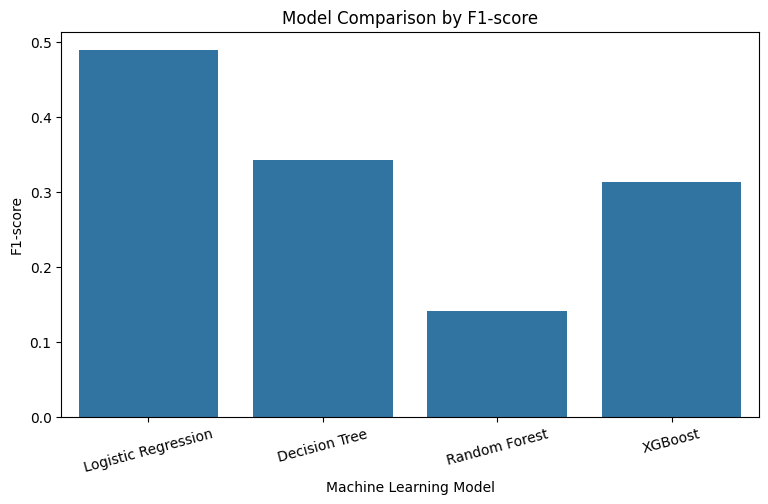

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1-score"
)

plt.title("Model Comparison by F1-score")
plt.xlabel("Machine Learning Model")
plt.ylabel("F1-score")

plt.xticks(rotation=15)

plt.show()

In [41]:
best_model_name = best_model_row["Model"]

model_dictionary = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

best_model = model_dictionary[
    best_model_name
]

print(
    "Selected Best Model:",
    best_model_name
)

Selected Best Model: Logistic Regression


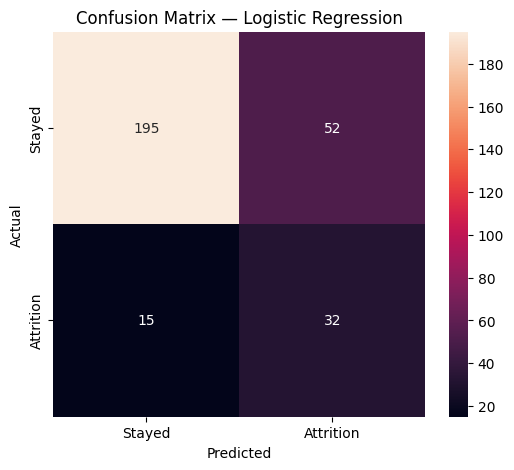

In [42]:
best_predictions = best_model.predict(
    X_test
)

best_cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Stayed",
        "Attrition"
    ],
    yticklabels=[
        "Stayed",
        "Attrition"
    ]
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [43]:
print(
    classification_report(
        y_test,
        best_predictions,
        target_names=[
            "Stayed",
            "Attrition"
        ]
    )
)

              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.85       247
   Attrition       0.38      0.68      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.80       294



## Save the Final Model

The best-performing complete pipeline is saved using Joblib. The saved object contains both preprocessing and the trained classifier, making it reusable for deployment.

In [ ]:
## Save the Final Model

The best-performing complete pipeline is saved using Joblib. The saved object contains both preprocessing and the trained classifier, making it reusable for deployment.

## Save the Final Model

The best-performing complete pipeline is saved using Joblib. The saved object contains both preprocessing and the trained classifier, making it reusable for deployment.

In [44]:
model_filename = "workforceiq_attrition_model.joblib"

joblib.dump(
    best_model,
    model_filename
)

print(
    "Model saved successfully as:",
    model_filename
)

Model saved successfully as: workforceiq_attrition_model.joblib


In [45]:
print(
    "File exists:",
    os.path.exists(
        model_filename
    )
)

print(
    "File size:",
    os.path.getsize(
        model_filename
    ),
    "bytes"
)

File exists: True
File size: 9130 bytes


In [46]:
loaded_model = joblib.load(
    model_filename
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [47]:
print("WORKFORCEIQ FINAL RESULTS")
print("=" * 50)

print(
    "\nBest Model:",
    best_model_name
)

print(
    "\nModel Comparison:\n"
)

print(
    comparison_df.round(4)
)

WORKFORCEIQ FINAL RESULTS

Best Model: Logistic Regression

Model Comparison:

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0  Logistic Regression    0.7721     0.3810  0.6809    0.4885   0.8075
1        Decision Tree    0.7381     0.2857  0.4255    0.3419   0.5361
2        Random Forest    0.8333     0.4000  0.0851    0.1404   0.7682
3              XGBoost    0.8503     0.5882  0.2128    0.3125   0.7840


## Conclusion

This capstone project developed a complete machine learning solution for employee attrition risk prediction. The workflow included data inspection, exploratory data analysis, data cleaning, feature engineering, preprocessing, training multiple classification models, model evaluation, and final model selection.

Logistic Regression, Decision Tree, Random Forest, and XGBoost were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC. The best-performing model was selected based primarily on F1-score because employee attrition is an imbalanced classification problem.

The final preprocessing and machine learning model were combined into a reusable pipeline and saved using Joblib. This pipeline will be used to build and deploy the WorkforceIQ Streamlit application.

## WorkforceIQ — Employee Attrition Prediction Case Study

Employee turnover can create significant operational challenges for organizations. When experienced employees leave, companies may face recruitment costs, onboarding expenses, productivity losses, and the loss of valuable organizational knowledge. WorkforceIQ was developed as a machine learning decision-support system designed to identify patterns associated with employee attrition.

The project uses historical employee information including job role, overtime, income, satisfaction levels, work-life balance, career experience, and tenure. After cleaning and exploring the data, additional features were engineered to better represent employee satisfaction, career stability, and income relative to experience. Multiple machine learning algorithms were then trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Because employee attrition represents a smaller proportion of the workforce, model evaluation focused not only on accuracy but also on Precision, Recall, F1-score, and ROC-AUC. This provides a more realistic understanding of how effectively the model identifies employees who may be at higher risk of leaving.

The final system is intended to support HR decision-making rather than replace human judgment. Organizations could use predictions alongside qualitative information to identify areas requiring attention, such as excessive overtime, low satisfaction, limited career progression, or poor work-life balance. The project demonstrates how machine learning can convert historical HR data into actionable insights that may support employee retention and workforce planning.
